In [1]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters
from lignin_saf.settings.prices import prices
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank




chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_CRUDE_OUT)
monomer_purification_sys = create_monomer_purification_system(ins=F.PURE_OIL_OUT)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.MON_MONOMERS_OUT)
hdo_system.simulate()

etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp, add_denaturant=False)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()

# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()


WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.WW_10, F.WastePulp, F.RCF_WW_OUTS, F.WW_11, F.WW_12, F.HDO_WW, F.HDO_wash_water, F.ETJ_WW_OUTS] + etoh_ww)

for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)


BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])


gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.RCF_PSAWASTE_OUTS, F.HDO_purge_gases, F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF


combined_saf = bst.units.Mixer(ins = (F.ETJ_SAF_OUT, F.HDO_CYCLOALKANES_OUT), outs = 'TOTAL_SAF', rigorous = True)

h2_rcf = bst.Stream()
h2_rcf.copy_like(F.RCF_H2_IN)

h2_hdo = bst.Stream()
h2_hdo.copy_like(F.HDO_H2_IN)

h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

# Shared H2 storage — sized from combined ETJ + HDO fresh H2 demand
h2_feed_mixer = bst.Mixer('H2_FEED_MIX', ins=(h2_rcf, h2_hdo, h2_etj))
shared_h2_storage = HydrogenStorageTank('H2_TK', ins=h2_feed_mixer.outs[0])


rcf_pure_mon_hdo_etoh_etj_system = bst.System(
    'RCF+HDO+Cellulosic_ETJ',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, etoh_system, etj_system, combined_saf, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_feed_mixer, shared_h2_storage, BT],
)

rcf_pure_mon_hdo_etoh_etj_system.simulate()

F.ETJ_H2_IN.price = prices['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = prices['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = prices['renewable_diesel']    # 1.888 USD/kg
#F.sulfuric_acid.price = prices['H2SO4']
#F.ammonia.price = prices['NH3']
F.cellulase.price = prices['Cellulase'] 
F.CSL.price = prices ['CSL'] 
F.DAP.price = prices['DAP'] 
F.caustic.price = prices['Caustic']
F.denaturant.price =  prices['Denaturant'] 
F.cooling_tower_chemicals.price = prices['CT_chemicals'] 
#F.FGD_lime.price = prices['FOD_lime']
#F.boiler_chemicals.price = prices['Boiler_chemicals'] 


integrated_tea = create_cellulosic_ethanol_tea(rcf_pure_mon_hdo_etoh_etj_system)





c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.22e-07 m2/s), and NPSH (3.89 ft); assuming centrigugal pump
  warn(f'{repr(

In [2]:
integrated_tea.labor_cost = labor
integrated_tea.operating_days = 330
mjsp = round(((integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172),2)

print(f'The MSP for SAF blend is  {mjsp} USD/gal')


The MSP for SAF blend is  22.08 USD/gal


In [3]:
F.RCF_RXR2.results()

Hydrogenolysis reactor                               Units  RCF_RXR2
High pressure steam Duty                             kJ/hr  1.85e+07
                    Flow                           kmol/hr       575
                    Cost                            USD/hr       182
Design              Diameter                            ft      13.9
                    Length                              ft      41.8
                    Reactor volume                      m3       180
                    Total volume                        m3       902
                    Residence time                      hr     0.333
                    Number of reactors                             5
                    Vessel type                             Vertical
                    Weight                              lb  6.49e+05
                    Wall thickness                      in      6.92
                    Duty                             kJ/hr  1.57e+07
Purchase cost       Vertical pressure vessel (x5)      USD  1.38e+07
                    Platform and ladders (x5)          USD  2.98e+05
                    Catalyst loading cost (x5)         USD  1.04e+05
Total purchase cost                                    USD  1.42e+07
Utility cost                                        USD/hr       182

In [4]:
F.M301.solids_loading

0.2

In [5]:
from lignin_saf.settings.process_params import hdo_params

In [6]:
monomer_flow = F.HDO_RXR1.ins[0].imass['Propylguaiacol'] + F.HDO_RXR1.ins[0].imass['Propylsyringol']

In [7]:
total = prices['HDO_Cat'] * hdo_params['catalyst_req'] * monomer_flow * 5


In [8]:
total/1e6

3.65683577024665

In [9]:
F.ETJ_RXR1.pressure

1063000.0

In [10]:
F.ETJ_RXR1.WHSV

0.3

In [11]:
F.ETJ_RXR1.catalyst_lifetime

2

In [12]:
F.M301.results()

Enzyme hydrolysate mixer        Units     M301
Electricity         Power          kW      110
                    Cost       USD/hr     9.09
Design              Flow rate   kg/hr 5.61e+05
Purchase cost       Mixer         USD 2.13e+05
Total purchase cost               USD 2.13e+05
Utility cost                   USD/hr     9.09

In [13]:
F.TOTAL_SAF

Stream: TOTAL_SAF from <Mixer: M3>
phase: 'l', T: 288.15 K, P: 101325 Pa
flow (kmol/hr): Water              0.0263
                Ethanol            0.0183
                Hexane             0.566
                propylcyclohexane  26.2
                Decane             56
                Octadecane         0.565
                Dodecane           0.0958


In [14]:
F.RCF_RXR1.results()

Solvolysis reactor                                  Units  RCF_RXR1
Electricity         Power                              kW      45.1
                    Cost                           USD/hr      3.73
Design              Diameter                           ft      11.9
                    Length                             ft      59.7
                    Reactor volume                     m3       189
                    Total volume                       m3       756
                    Total beds                                    4
                    Beds in service                               3
                    Time on stream                     hr         3
                    Residence time                     hr       0.3
                    Turnaround time                    hr         1
                    Batch time                         hr         4
                    Biomass volume per bed             m3       172
                    Solvent volume per bed             m3      94.5
                    Instantaneous loading            L/kg      1.13
                    Solvent loading                  L/kg      11.3
                    Vessel type                            Vertical
                    Weight                             lb  6.31e+05
                    Wall thickness                     in      5.95
                    Pressure drop                     bar     0.013
Purchase cost       Vertical pressure vessel (x4)     USD  1.08e+07
                    Platform and ladders (x4)         USD  2.74e+05
                    Pump 1 - Pump (x4)                USD  2.54e+05
                    Pump 1 - Motor (x4)               USD  3.98e+03
Total purchase cost                                   USD  1.13e+07
Utility cost                                       USD/hr      3.73

In [15]:

tau_0 = 0.001
tau = 3
cycle_time =  tau + tau_0

In [16]:
N_total_base   = np.ceil(tau_0 + tau)
N_working_base = np.ceil(N_total_base * (tau/np.ceil(cycle_time)))

In [17]:
N_working_base

3.0

In [18]:
N_total_base

4.0

# Parameters for local sensitivity analysis - checking their baseline

In [19]:
# Operating days
integrated_tea.operating_days 


330.0

In [20]:
# Feedstock price
from lignin_saf.settings.prices import _feedstock_price_dry_ton
_feedstock_price_dry_ton

70

In [21]:
# Labor cost
integrated_tea.labor_cost/1e6

17.88924

In [22]:
# Electricity price
bst.settings.electricity_price

0.0826

In [23]:
# Renewable naphtha price
F.ETJ_RN_OUT.price

0.57

In [24]:
# Renewable diesel price
F.ETJ_RD_OUT.price

1.2765889862263224

In [25]:
# Hydrogen price
prices['Hydrogen']

3.6999999999999997

In [26]:
# Hydrogen storage period
F.H2_TK.storage_period

0.5

In [27]:
F.ETJ_RXR1.temperature

754.15

In [28]:
# import pandas as pd
# from IPython.display import display
# 
# records = []
# 
# for unit in rcf_pure_mon_hdo_etoh_etj_system.units:    # system name is my_sys here
#     heat_utilities = getattr(unit, 'heat_utilities', [])  # Default to empty list if not present
#     total_duty = sum(h.duty for h in heat_utilities if h.duty != 0)  # Can also use h.duty > 0 for heating only
# 
#     records.append({
#         'Unit ID': unit.ID,
#         'Unit Type': type(unit).__name__,
#         'Utility [kJ/hr]': total_duty
#     })
# 
# df_opex = pd.DataFrame(records)
# 
# # Remove zero-utility rows (optional)
# df_opex = df_opex[df_opex['Utility [kJ/hr]'] != 0]
# 
# # Sort in descending order of heat duty
# df_opex = df_opex.sort_values(by='Utility [kJ/hr]', ascending=False).reset_index(drop=True)
# 
# total_heat = df_opex['Utility [kJ/hr]'].sum()
# df_opex['% of Total'] = df_opex['Utility [kJ/hr]'] / total_heat 
# df_opex.to_excel('heat_utilities_summary.xlsx', index=False)
# 
# display(df_opex)

In [29]:
#def find_units_using_agent(agent_ID, system=rcf_pure_mon_hdo_etoh_etj_system):
#    agent = bst.settings.get_agent(agent_ID)
#    if not agent:
#        print(f"No agent found with ID '{agent_ID}'")
#        return []
#
#    if system is None:
#        system = bst.main_flowsheet.rcf_pure_mon_hdo_etoh_etj_system    # Assynes systems name is my_sys
#
#    units_using_agent = []
#
#    for unit in system.units:
#        if hasattr(unit, 'heat_utilities'):
#            for hu in unit.heat_utilities:
#                if hu.agent is agent:
#                    units_using_agent.append((unit.ID, hu.duty, hu.agent.ID))
#
#    return units_using_agent
#
## Example usage
#results = find_units_using_agent('natural_gas')
#
## Display results
#if results:
#    print(f"\nUnits using agent 'ethylene':")
#    for ID, duty, agent_ID in results:
#        print(f" - Unit {ID} | Duty: {duty:.2f} kJ  | Agent: {agent_ID}")
#else:
#    print("No units are using this agent.")

In [30]:
h2_requirements_rcf = h2_rcf.F_mass*24
h2_requirements_hdo = h2_hdo.F_mass*24
h2_requirements_etj = h2_etj.F_mass*24
total_biorefinery_h2 = h2_requirements_rcf + h2_requirements_hdo + h2_requirements_etj
print(f'The biorefinery daily hydrogen requirement is {round(total_biorefinery_h2,1)}kg')

The biorefinery daily hydrogen requirement is 28444.1kg


In [31]:
h2_requirements_hdo

11536.209110434667

In [32]:
### Hydrogen requirements breakdown plot
#import matplotlib.pyplot as plt
#import matplotlib.patches as mpatches
#import numpy as np
#
## --- Data ---
#a = h2_requirements_rcf
#b = h2_requirements_hdo
#c = h2_requirements_etj
#total = a + b + c
#
#values = [a, b, c]
#labels = ["a", "b", "c"]
#
## --- Style ---
#plt.rcParams.update({
#    "font.family": "sans-serif",
#    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
#    "font.size": 9,
#    "axes.spines.top": False,
#    "axes.spines.right": False,
#    "axes.spines.left": False,
#    "axes.spines.bottom": False,
#    "xtick.bottom": False,
#    "ytick.left": False,
#    "xtick.labelbottom": False,
#    "ytick.labelleft": False,
#    "figure.dpi": 300,
#})
#
#colors = ["#3C3489", "#1D9E75", "#D85A30"]   # purple, teal, coral
#
#fig, ax = plt.subplots(figsize=(2.8, 4.2))
#
#bar_width = 0.42
#x = 0
#
#bottom = 0
#bars = []
#for val, color in zip(values, colors):
#    bar = ax.bar(x, val, width=bar_width, bottom=bottom,
#                 color=color, linewidth=0)
#    bars.append(bar)
#    bottom += val
#
## --- Value labels inside each segment ---
#bottom = 0
#for val, color in zip(values, colors):
#    mid = bottom + val / 2
#    # only label if segment is tall enough to read
#    if val / total > 0.08:
#        ax.text(x, mid, f"{val:,.0f}",
#                ha="center", va="center",
#                fontsize=8, color="white", fontweight="bold")
#    bottom += val
#
## --- Total label above bar ---
#ax.text(x, total + total * 0.015, f"{total:,.0f}",
#        ha="center", va="bottom", fontsize=8.5,
#        color="#2C2C2A", fontweight="bold")
#
## --- Axis limits ---
#ax.set_xlim(-0.5, 0.5)
#ax.set_ylim(0, total * 1.12)
#ax.set_xticks([])
#ax.set_yticks([])
#
## --- Legend ---
#patches = [
#    mpatches.Patch(color=colors[i], label=f"{labels[i]}  {values[i]:,.0f}")
#    for i in range(len(labels))
#]
#ax.legend(
#    handles=patches,
#    loc="upper right",
#    bbox_to_anchor=(2.05, 1.0),
#    frameon=False,
#    fontsize=8.5,
#    handlelength=1.0,
#    handleheight=1.0,
#    borderpad=0,
#    labelspacing=0.55,
#)
#
#fig.tight_layout()
#plt.savefig("stacked_bar.svg", dpi=300, bbox_inches="tight", transparent=False)
#plt.show()


In [33]:
F.M301.solids_loading

0.2

In [34]:
import biorefineries as bg

In [35]:
bg.__version__

'2.34.10'

In [36]:
F.M301.enzyme_loading

0.02

In [37]:
#import pandas as pd
#
#for u in rcf_pure_mon_hdo_etoh_etj_system.cost_units:
#    print(f"{u.ID}: {round(u.purchase_cost/1e6,2)} MM USD")

In [38]:
#import pandas as pd
#
#purchase_df = pd.DataFrame({
#    'Unit': [u.ID for u in rcf_pure_mon_hdo_etoh_etj_system.cost_units],                          # The system here is named my_sys
#    'Purchase Cost': [u.purchase_cost for u in rcf_pure_mon_hdo_etoh_etj_system.cost_units]
#})
#purchase_df.to_excel('equipment_purchase_costs_2.xlsx', index=False)

In [39]:
import thermosteam as tmo
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [40]:
# Different sections

rcf = [F.MIX100, F.RCF_PUMP1, F.RCF_HX1, F.RCF_RXR1, F.RCF_MIX2, F.RCF_HX2, F.RCF_RXR2, F.RCF_FLSH1, F.RCF_COMP1,
F.RCF_FLSH2, F.RCF_HX3, F.RCF_PSA1, F.RCF_PUMP2, F.RCF_COL1, F.RCF_COL2, F.RCF_MIX3, F.RCF_HX4, F.RCF_FLSH3, F.RCF_MIX4, F.RCF_FLSH4]

oil = [F.MIX200, F.LLE200, F.FLASH201, F.HX202, F.CENT203]

monomer = [F.MIX300, F.LLE300, F.FLASH301, F.HX302, F.CENT303]

hdo = [F.HDO_MIX1, F.HDO_MIX2, F.HDO_MIX3, F.HDO_COMP1, F.HDO_HX1, F.HDO_RXR1, F.HDO_HX2, F.HDO_V1, F.HDO_FLSH1,  F.HDO_FLSH2, F.HDO_HX3, F.HDO_PSA1, F.HDO_COMP_H2, F.HDO_COL1, F.HDO_HX_DOD, F.HDO_COL2,
       F.HDO_HX4, F.HDO_TK1]

etoh = [F.M301, F.H301, F.R301, F.DAP_storage, F.S301, F.CSL_storage, F.S302, F.R303, F.R302, F.T301, F.M304, F.D401, F.M401, F.T302, F.P401, F.H401, F.D402, F.P401, F.D403, F.H402, F.U401, F.H403, 
        F.T701, F.P701, F.T702, F.P702, F.M701, F.T703, F.P403, F.M1, F.S401 ]


etj = [F.ETJ_MIX1, F.ETJ_PUMP1, F.ETJ_HX1, F.ETJ_MIX2, F.ETJ_HX2, F.ETJ_RXR1, F.ETJ_SPLIT1, F.ETJ_FLSH1, F.ETJ_COMP1, F.ETJ_COL1, F.ETJ_COMP2, F.ETJ_COL2, F.ETJ_HX3, F.ETJ_MIX3, F.ETJ_RXR2, 
        F.ETJ_SPLIT2,  F.ETJ_MIX4,  F.ETJ_HX4, F.ETJ_RXR3, F.ETJ_HX5, F.ETJ_FLSH2, F.ETJ_SPLIT3, F.ETJ_COL3, F.ETJ_COL4, F.ETJ_HX6, F.ETJ_HX7, F.ETJ_HX8, F.ETJ_TK1, F.ETJ_TK2, F.ETJ_TK3, F.ETJ_WW_MIX, 
        F.ETJ_CAT_MIX]

other_utilities = [F.CWP, F.CT, F.FWT, F.ADP, F.PWC]

BT = [BT]

WWT = [WWT]

In [41]:
rcf_area_ic = sum(u.installed_cost for u in rcf)
rcf_oil_purification_ic = sum(u.installed_cost for u in oil)
rcf_monomer_purification_ic = sum(u.installed_cost for u in monomer)
etoh_ic =  sum(u.installed_cost for u in etoh)
etj_ic = sum(u.installed_cost for u in etj)
hdo_ic = sum(u.installed_cost for u in hdo)
BT_installed_cost = F.BT.installed_cost
WWT_installed_cost  = F.WWTC.installed_cost
other_utilities_ic = sum(u.installed_cost for u in other_utilities)
h2_storage_ic = F.H2_TK.installed_cost
installed_costs_arr = np.array([rcf_area_ic, rcf_oil_purification_ic, rcf_monomer_purification_ic, hdo_ic, etoh_ic, etj_ic, other_utilities_ic,
                            BT_installed_cost, WWT_installed_cost, h2_storage_ic])


Font: Arial


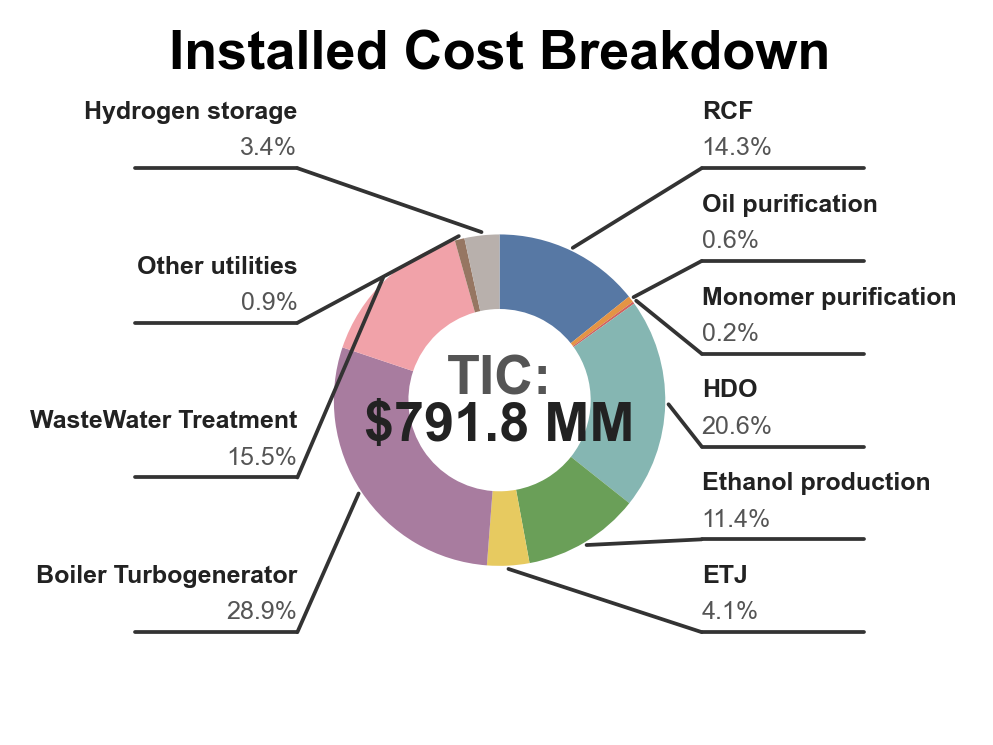

In [42]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})
plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    '#5778a4', '#e49444', '#d1615d', '#85b6b2', '#6a9f58',
    '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac', "#8D86C9"
]

categories = [
    "RCF", "Oil purification", "Monomer purification", "HDO",
    "Ethanol production", "ETJ", "Boiler Turbogenerator",
    "WasteWater Treatment", "Other utilities", "Hydrogen storage"
]

values = [
    rcf_area_ic, rcf_oil_purification_ic, rcf_monomer_purification_ic,
    hdo_ic, etoh_ic, etj_ic, BT_installed_cost, WWT_installed_cost,
    other_utilities_ic, h2_storage_ic
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_in = 1500/1.4 / DPI
fig_h_in = 1260/1.4 / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 6
FS_LEGEND = 6

DONUT_WIDTH = 0.45   # ← controls ring thickness (0–1); increase to thicken

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))




DONUT_WIDTH = 0.45

def draw_donut(ax, vals, title):
    total = sum(vals)
    fracs = [v / total for v in vals]
    n = len(vals)

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors[:n],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(
            width=DONUT_WIDTH,
            linewidth=0,          # ← no borders between segments
            edgecolor="none",
        ),
    )

    # ── Center label ──────────────────────────────────────────────────────
    ax.text(0,  0.12, "TIC:",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#555555")
    ax.text(0, -0.16,
            f"${rcf_pure_mon_hdo_etoh_etj_system.installed_cost/1e6:.1f} MM",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#222222")

    r_outer = 1.0

    # ── Collect label info ────────────────────────────────────────────────
    label_info = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        label_info.append({
            "theta":    theta,
            "pct":      pct,
            "cat":      categories[i],
            "is_right": np.cos(theta) >= 0,
        })

    # ── Split into left/right, sorted top → bottom by sin(theta) ─────────
    right = sorted([d for d in label_info if     d["is_right"]],
                   key=lambda d: np.sin(d["theta"]), reverse=True)
    left  = sorted([d for d in label_info if not d["is_right"]],
                   key=lambda d: np.sin(d["theta"]), reverse=True)

    # ── Evenly distribute y positions across each side ────────────────────
    Y_TOP, Y_BOT = 1.40, -1.40

    def y_positions(n_labels):
        return list(np.linspace(Y_TOP, Y_BOT, n_labels)) if n_labels > 1 else [0.0]

    right_ys = y_positions(len(right))
    left_ys  = y_positions(len(left))

    # ── Fixed x anchors ───────────────────────────────────────────────────
    # "conn" = where the diagonal meets the underline
    # "far"  = the far end of the underline
    X_R_CONN, X_R_FAR = 1.22,  2.20
    X_L_CONN, X_L_FAR = -1.22, -2.20

    # ── Draw each group ───────────────────────────────────────────────────
    GAP    = 0.05   # gap between underline and bottom of percentage text
    LINE_H = 0.22   # vertical distance between percentage and category name

    def draw_group(group, ys, is_right):
        x_conn = X_R_CONN if is_right else X_L_CONN
        x_far  = X_R_FAR  if is_right else X_L_FAR
        ha     = "left"   if is_right else "right"

        for d, y_line in zip(group, ys):
            theta = d["theta"]
            pct   = d["pct"]
            cat   = d["cat"]

            # Point just outside the outer ring
            x0 = (r_outer + 0.02) * np.cos(theta)
            y0 = (r_outer + 0.02) * np.sin(theta)

            # ── Diagonal leader line ──────────────────────────────────────
            ax.plot([x0, x_conn], [y0, y_line],
                    color="#333333", lw=0.9, solid_capstyle="round",
                    clip_on=False, zorder=5)

            # ── Horizontal underline ──────────────────────────────────────
            ax.plot([x_conn, x_far], [y_line, y_line],
                    color="#333333", lw=0.9, solid_capstyle="round",
                    clip_on=False, zorder=5)

            # ── Percentage (just above underline) ─────────────────────────
            ax.text(x_conn, y_line + GAP,
                    f"{pct:.1f}%",
                    ha=ha, va="bottom",
                    fontsize=FS_PCT,
                    color="#555555",
                    clip_on=False)

            # ── Category name (bold, above percentage) ────────────────────
            ax.text(x_conn, y_line + GAP + LINE_H,
                    cat,
                    ha=ha, va="bottom",
                    fontsize=FS_PCT,
                    fontweight="bold",
                    color="#222222",
                    clip_on=False)

    draw_group(right, right_ys, is_right=True)
    draw_group(left,  left_ys,  is_right=False)

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(-1.9, 1.75)


draw_donut(ax, values, "Installed Cost Breakdown")

# ── DELETE the fig.legend(...) block entirely ──────────────────────────────

plt.rcParams['svg.fonttype'] = 'none'
fig.tight_layout(rect=[0, 0.02, 1, 1])   # was [0, 0.14, 1, 1]
fig.savefig("installed_cost_breakdown_5.svg", format="svg", bbox_inches="tight")

Font: Arial
Done.


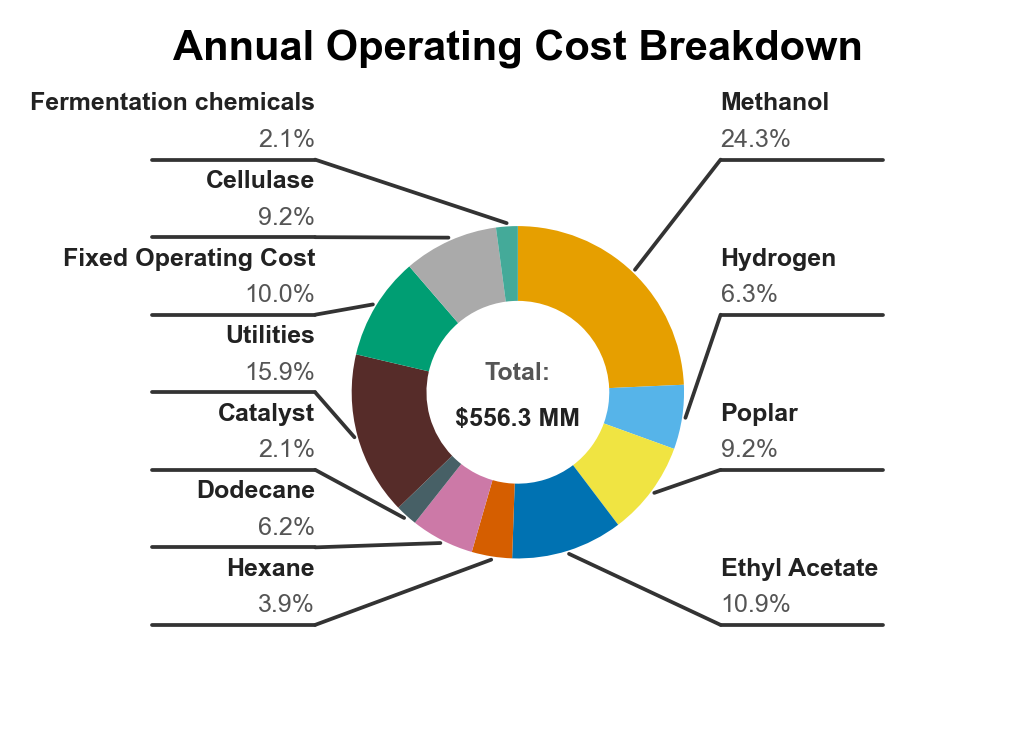

In [43]:
# Operating costs plot
methanol_price = F.RCF_MEOH_IN.F_mass * prices['Methanol'] * integrated_tea.operating_hours
hydrogen_price = (F.RCF_H2_IN.F_mass + F.HDO_H2_IN.F_mass + F.ETJ_H2_IN.F_mass) * prices['Hydrogen'] * integrated_tea.operating_hours
poplar_price = F.Poplar_In.F_mass * prices['Feedstock'] * integrated_tea.operating_hours
ethyl_acetate_price = F.EthylAcetate_in.F_mass * prices['EthylAcetate'] * integrated_tea.operating_hours
hexane_price = F.Hexane_In.F_mass * prices['Hexane'] * integrated_tea.operating_hours
dodecane_price = F.HDO_DODECANE_IN.F_mass * prices['Dodecane'] * integrated_tea.operating_hours
catalyst = (
    F.RCF_CAT_IN.F_mass * prices['NiC_catalyst']
    + F.HDO_CAT_IN.F_mass * prices['HDO_Cat']
    + F.Dehyd_cat_replacement.F_mass * prices['dehydration_catalyst']
    + F.Olig_cat_replacement.F_mass * prices['oligomerization_catalyst']
    + F.Hydgn_cat_replacement.F_mass * prices['hydrogenation_catalyst']
) * integrated_tea.operating_hours
# ── Cellulosic ethanol process chemicals ──────────────────────────────────────
cellulase_cost = F.cellulase.F_mass * prices['Cellulase'] * integrated_tea.operating_hours

# NOTE: F.denaturant has zero flow (add_denaturant=False), so it contributes $0.
# Included here for completeness — it is priced and appears in the TEA material_cost.
fermentation_chems_cost = (
    F.CSL.F_mass * prices['CSL']
    + F.DAP.F_mass * prices['DAP']
    + F.caustic.F_mass * prices['Caustic']
    + F.denaturant.F_mass * prices['Denaturant']
    + F.cooling_tower_chemicals.F_mass * prices['CT_chemicals']
) * integrated_tea.operating_hours
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})
plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#476066",  # dark teal
    "#562C29",  # dark brown
    "#009E73",  # bluish green
     "#AAAAAA",  # medium gray  — Cellulase
    "#44AA99",  # muted teal   — Fermentation Chemicals
]

categories = [
    "Methanol",
    "Hydrogen",
    "Poplar",
    "Ethyl Acetate",
    "Hexane",
    "Dodecane",
    "Catalyst",
    "Utilities",
    "Fixed Operating Cost",
    "Cellulase",
    "Fermentation chemicals"
]

values = [
    methanol_price,
    hydrogen_price,
    poplar_price,
    ethyl_acetate_price,
    hexane_price,
    dodecane_price,
    catalyst,
    integrated_tea.utility_cost,
    integrated_tea.FOC,
    cellulase_cost,
    fermentation_chems_cost
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_in = 1500/1.4 / DPI
fig_h_in = 1260/1.4 / DPI

FS_TITLE  = 10
FS_TOTAL  = 6
FS_PCT    = 6

DONUT_WIDTH = 0.45

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_donut ────────────────────────────────────────────────────────────────
def draw_donut(ax, vals, title):
    total = sum(vals)
    fracs = [v / total for v in vals]
    n = len(vals)

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors[:n],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(
            width=DONUT_WIDTH,
            linewidth=0,
            edgecolor="none",
        ),
    )

    # ── Center label ──────────────────────────────────────────────────────
    ax.text(0,  0.12, "Total:",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#555555")
    ax.text(0, -0.16,
            f"${total/1e6:.1f} MM",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#222222")

    r_outer = 1.0

    # ── Collect label info ────────────────────────────────────────────────
    label_info = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        label_info.append({
            "theta":    theta,
            "pct":      pct,
            "cat":      categories[i],
            "is_right": np.cos(theta) >= 0,
        })

    # ── Split left/right, sorted top → bottom ────────────────────────────
    right = sorted([d for d in label_info if     d["is_right"]],
                   key=lambda d: np.sin(d["theta"]), reverse=True)
    left  = sorted([d for d in label_info if not d["is_right"]],
                   key=lambda d: np.sin(d["theta"]), reverse=True)

    # ── Evenly distribute y positions on each side ────────────────────────
    Y_TOP, Y_BOT = 1.40, -1.40

    def y_positions(n_labels):
        return list(np.linspace(Y_TOP, Y_BOT, n_labels)) if n_labels > 1 else [0.0]

    right_ys = y_positions(len(right))
    left_ys  = y_positions(len(left))

    # ── Fixed x anchors ───────────────────────────────────────────────────
    X_R_CONN, X_R_FAR = 1.22,  2.20
    X_L_CONN, X_L_FAR = -1.22, -2.20

    GAP    = 0.05   # gap between underline and bottom of percentage text
    LINE_H = 0.22   # vertical step from percentage to category name

    def draw_group(group, ys, is_right):
        x_conn = X_R_CONN if is_right else X_L_CONN
        x_far  = X_R_FAR  if is_right else X_L_FAR
        ha     = "left"   if is_right else "right"

        for d, y_line in zip(group, ys):
            theta = d["theta"]
            pct   = d["pct"]
            cat   = d["cat"]

            # Start just outside the outer ring
            x0 = (r_outer + 0.02) * np.cos(theta)
            y0 = (r_outer + 0.02) * np.sin(theta)

            # Diagonal leader line
            ax.plot([x0, x_conn], [y0, y_line],
                    color="#333333", lw=0.9, solid_capstyle="round",
                    clip_on=False, zorder=5)

            # Horizontal underline
            ax.plot([x_conn, x_far], [y_line, y_line],
                    color="#333333", lw=0.9, solid_capstyle="round",
                    clip_on=False, zorder=5)

            # Percentage just above underline
            ax.text(x_conn, y_line + GAP,
                    f"{pct:.1f}%",
                    ha=ha, va="bottom",
                    fontsize=FS_PCT,
                    color="#555555",
                    clip_on=False)

            # Category name bold, above percentage
            ax.text(x_conn, y_line + GAP + LINE_H,
                    cat,
                    ha=ha, va="bottom",
                    fontsize=FS_PCT,
                    fontweight="bold",
                    color="#222222",
                    clip_on=False)

    draw_group(right, right_ys, is_right=True)
    draw_group(left,  left_ys,  is_right=False)

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(-1.9, 1.75)


draw_donut(ax, values, "Annual Operating Cost Breakdown")

plt.rcParams['svg.fonttype'] = 'none'
fig.tight_layout(rect=[0, 0.02, 1, 1])

fig.savefig("operating_breakdown_3.svg", format="svg", bbox_inches="tight")
print("Done.")

In [44]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
from lignin_saf.settings.process_params import solvolysis_params
from lignin_saf.settings.prices import prices, _feedstock_price_dry_ton, kg_per_ton, h2_price

model = bst.Model(rcf_pure_mon_hdo_etoh_etj_system)

from chaospy import distributions as shape
param = model.parameter


In [ ]:
var_50 = 0.5 # 50% variation in parameters - set for a few
var_20 = 0.2 # 20% variation in other parameters

In [ ]:
# Operating days
dist = shape.Uniform(lower = 297 , upper = 363)
@param(name = 'Operating days',
    element = 'Overall',
    kind = 'coupled',
    units = 'days',
    baseline = integrated_tea.operating_days,
    distribution = dist)
def set_opertaing_days(i): 
    integrated_tea.operating_days = i


# Poplar feedstock
dist = shape.Uniform(lower = 50 , upper = 100)
@param(name = 'Poplar feedstock price',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/DMT',
    baseline = _feedstock_price_dry_ton,
    distribution = dist)
def set_poplar_feedstock_price(i):
    # i is in USD/dry short ton; stream price must be USD/kg wet biomass
    F.Poplar_In.price = i / kg_per_ton / (1 + feed_parameters['moisture'])



# Labor cost
dist = shape.Uniform(lower = integrated_tea.labor_cost * (1-var_50) , upper = integrated_tea.labor_cost * (1+var_50) )
@param(name = 'Labor cost',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/yr',
    baseline = integrated_tea.labor_cost,
    distribution = dist)
def set_labor_cost(i): 
    integrated_tea.labor_cost = i


# Renewable napthha co-product revenue
dist = shape.Uniform(lower = 0.505 , upper = 0.77)
@param(name = 'RN co-product credit',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/kg',
    baseline =  F.ETJ_RN_OUT.price,
    distribution = dist)
def set_renewable_naptha_price(i): 
    F.ETJ_RN_OUT.price = i            


# Biodiesel co-product revenue
dist = shape.Uniform(lower = 0.63 , upper = 1.48)
@param(name = 'RD co-product credit',
       element = 'Overall',
       kind = 'isolated',
       units = 'USD/kg',
       baseline =  F.ETJ_RD_OUT.price,
       distribution = dist)
def set_bio_diesel_price(i): 
     F.ETJ_RD_OUT.price = i



     
# Hydrogen price
dist = shape.Uniform(lower = 2.74 , upper = 11.53)
@param(name = 'Hydrogen price',
       element = 'Overall',
       kind = 'isolated',
       units = 'USD/kg',
       baseline =  h2_price,
       distribution = dist)
def set_hydrogen_price(i):
    h2_price = i


# Hydrogen storage time
dist = shape.Uniform(lower = 0.25 , upper = 3)
@param(name = 'Hydrogen storage period',
       element = 'Overall',
       kind = 'isolated',
       units = 'days',
       baseline =  F.H2_TK.storage_period,
       distribution = dist)
def set_h2_storage_period(i):
    F.H2_TK.storage_period = i


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.22e-07 m2/s), and NPSH (3.89 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (59.67 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:659: CostWarning: <HydrogenolysisReactor: RCF_RXR2> Vertical vessel length (41.79 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostW

0.5

3.6999999999999997

In [ ]:
metric = model.metric
@metric(name='Minimum Jet Selling Price', element='TEA', units='USD/gal')
def get_msp():
    msp = (integrated_tea.solve_price(F.TOTAL_SAF) * F.TOTAL_SAF.rho) / 264.172
    return msp


In [ ]:

from SALib.analyze import morris as morris_analyze

N_samples = 3000
rule = 'M'
np.random.seed(42)
problem = model.problem()
samples = model.sample(N_samples, rule, problem=problem, num_levels=6)
model.load_samples(samples)
model.evaluate()



In [ ]:
Y = model.table["TEA"]["Minimum jet selling price [USD/gal]"].to_numpy()


In [ ]:

Si = morris_analyze.analyze(
    problem,
    samples,
    Y,
    conf_level=0.95,
    print_to_console=True,
)


print("\n Morris Results")
results_df = pd.DataFrame({
    "Feature":  Si["names"],
    "µ*":       Si["mu_star"],
    "µ* conf":  Si["mu_star_conf"],
    "σ":        Si["sigma"],
})


                           mu  mu_star  sigma  mu_star_conf
Operating days          -2.62     31.9   31.9         0.246
Poplar feedstock price    1.8     1.99   1.46         0.102
Labor cost              -31.6     31.6   1.75          0.15
RN co-product credit   -0.326    0.761  0.909        0.0507

 Morris Results


In [ ]:
#bst.Model.load_default_parameters

In [ ]:
from lignin_saf.settings.process_params import solvolysis_params
from lignin_saf.settings.prices import prices, _feedstock_price_dry_ton

In [ ]:
model = bst.Model(rcf_pure_mon_hdo_etoh_etj_system)

In [ ]:
from chaospy import distributions as shape
param = model.parameter

In [ ]:
var_50 = 0.5 # 50% variation in parameters - set for a few
var_20 = 0.2 # 20% variation in other parameters

In [ ]:
# Operating days
dist = shape.Uniform(lower = 297 , upper = 363)
@param(name = 'Operating days',
       element = 'Overall',
       kind = 'coupled',
       units = 'days',
       baseline = integrated_tea.operating_days,
       distribution = dist)
def set_opertaing_days(i): 
    integrated_tea.operating_days = i

In [ ]:
problem = model.problem()

In [ ]:
metric = model.metric
@metric(name = 'Minimum Jet Selling Price', units = 'USD/gal', element = 'TEA')
def get_msp():
    msp = (integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172
    return msp

In [ ]:
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze


In [ ]:
problem = model.problem()

In [ ]:
param_values = morris_sample.sample(
    problem, N=100, num_levels=6, seed=42
)

In [ ]:
import numpy as np
N_samples = 100
rule = 'M'
np.random.seed()
problem = model.problem()
samples = model.sample(N_samples, rule, problem=problem, num_levels=6)
model.load_samples(samples)
model.evaluate(convergence_model="Average", notify=100)

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.22e-07 m2/s), and NPSH (3.89 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (59.67 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:659: CostWarning: <HydrogenolysisReactor: RCF_RXR2> Vertical vessel length (41.79 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostW

[100] Elapsed time: 40 sec


In [ ]:
Y = model.table["TEA"]["Minimum jet selling price [USD/gal]"].to_numpy()

In [ ]:
Si = morris_analyze.analyze(
    problem,
    samples,
    Y,
    conf_level=0.95,
    print_to_console=True,
)

ValueError: cannot reshape array of size 100 into shape (14,7)

In [ ]:
    print("\n Morris Results")
    results_df = pd.DataFrame({
        "Feature":  Si["names"],
        "µ*":       Si["mu_star"],
        "µ* conf":  Si["mu_star_conf"],
        "σ":        Si["sigma"],
    })


 Morris Results


NameError: name 'Si' is not defined

In [ ]:
import numpy as np
np.random.seed(3045)
samples = model.sample(N=100, rule = 'L')  # Change this to 3000 later
model.load_samples(samples)

In [ ]:
model.evaluate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.22e-07 m2/s), and NPSH (3.89 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (59.67 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:659: CostWarning: <HydrogenolysisReactor: RCF_RXR2> Vertical vessel length (41.79 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostW

In [ ]:
# Solvolysis residence time
dist = shape.Triangle(lower = 9/60, midpoint = solvolysis_params['tau_s_res'], upper = 36/60) 
@param(name = 'Solvolysis residence time',
     element = 'RCF', 
       kind = 'coupled',
       units = 'hr',
       baseline = solvolysis_params['tau_s_res'], distribution = dist)
def set_solvolysis_tau(i):
    F.RCF_RXR1.tau_residence = i  

In [ ]:
# Delignification
dist = shape.Uniform(lower = 0.4 , upper = 0.9)
@param(name = 'Delignfication',
  #     element = 'ATJ-TEA',
       kind = 'coupled',
       units = '%',
       baseline = solvolysis_parameters['Delignification'], distribution = dist)
def set_delignfication(i): 
    solvolysis_parameters['Delignification'] = i

In [ ]:
df_rho, df_p = model.spearman_r()
print(df_rho["TEA", "Minimum jet selling price [USD/gal]"])

Element  Parameter                       
Overall  Operating days [days]               -0.807
         Poplar feedstock price [USD/DMT]     0.115
         Labor cost [USD/yr]                  0.593
         Electricity price [USD/kWh]         0.0549
         RN co-product credit [USD/kg]      -0.0457
         RD co-product credit [USD/kg]       0.0113
Name: (TEA, Minimum jet selling price [USD/gal]), dtype: float64


In [ ]:
model.table.to_excel('uncertainty_analysis_results.xlsx')

In [ ]:
break

In [ ]:
import thermosteam as tmo
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [ ]:
parameters = model.get_baseline_sample()#.to_excel('model.xlsx', index=False)

In [ ]:
#parameters.to_excel('parameters.xlsx', index=True)

In [ ]:
model.load_default_parameters(poplar_in)

In [ ]:
model.parameters

(<Parameter: [Liquids centrifuge] Base cost (USD)>,
 <Parameter: [Liquids centrifuge] Exponent>,
 <Parameter: [Liquids centrifuge] Electricity rate (kW / m^3/hr)>,
 <Parameter: [Enzyme hydrolysate mixer] Mixer base cost (USD)>,
 <Parameter: [Enzyme hydrolysate mixer] Mixer exponent>,
 <Parameter: [Enzyme hydrolysate mixer] Mixer electricity rate (kW / kg/hr)>,
 <Parameter: [Hydrolysate heat exchanger] Heat exchanger base cost (USD)>,
 <Parameter: [Hydrolysate heat exchanger] Heat exchanger exponent>,
 <Parameter: [Continuous presaccharification] Tanks base cost (USD)>,
 <Parameter: [Continuous presaccharification] Tanks exponent>,
 <Parameter: [Continuous presaccharification] Transfer pumps base cost (USD)>,
 <Parameter: [Continuous presaccharification] Transfer pumps exponent>,
 <Parameter: [Continuous presaccharification] Transfer pumps electricity rate (kW / m3/hr)>,
 <Parameter: [DAPStorage tank] Bag unloader base cost (USD)>,
 <Parameter: [DAPStorage tank] Bag unloader exponent>,


Font: Arial


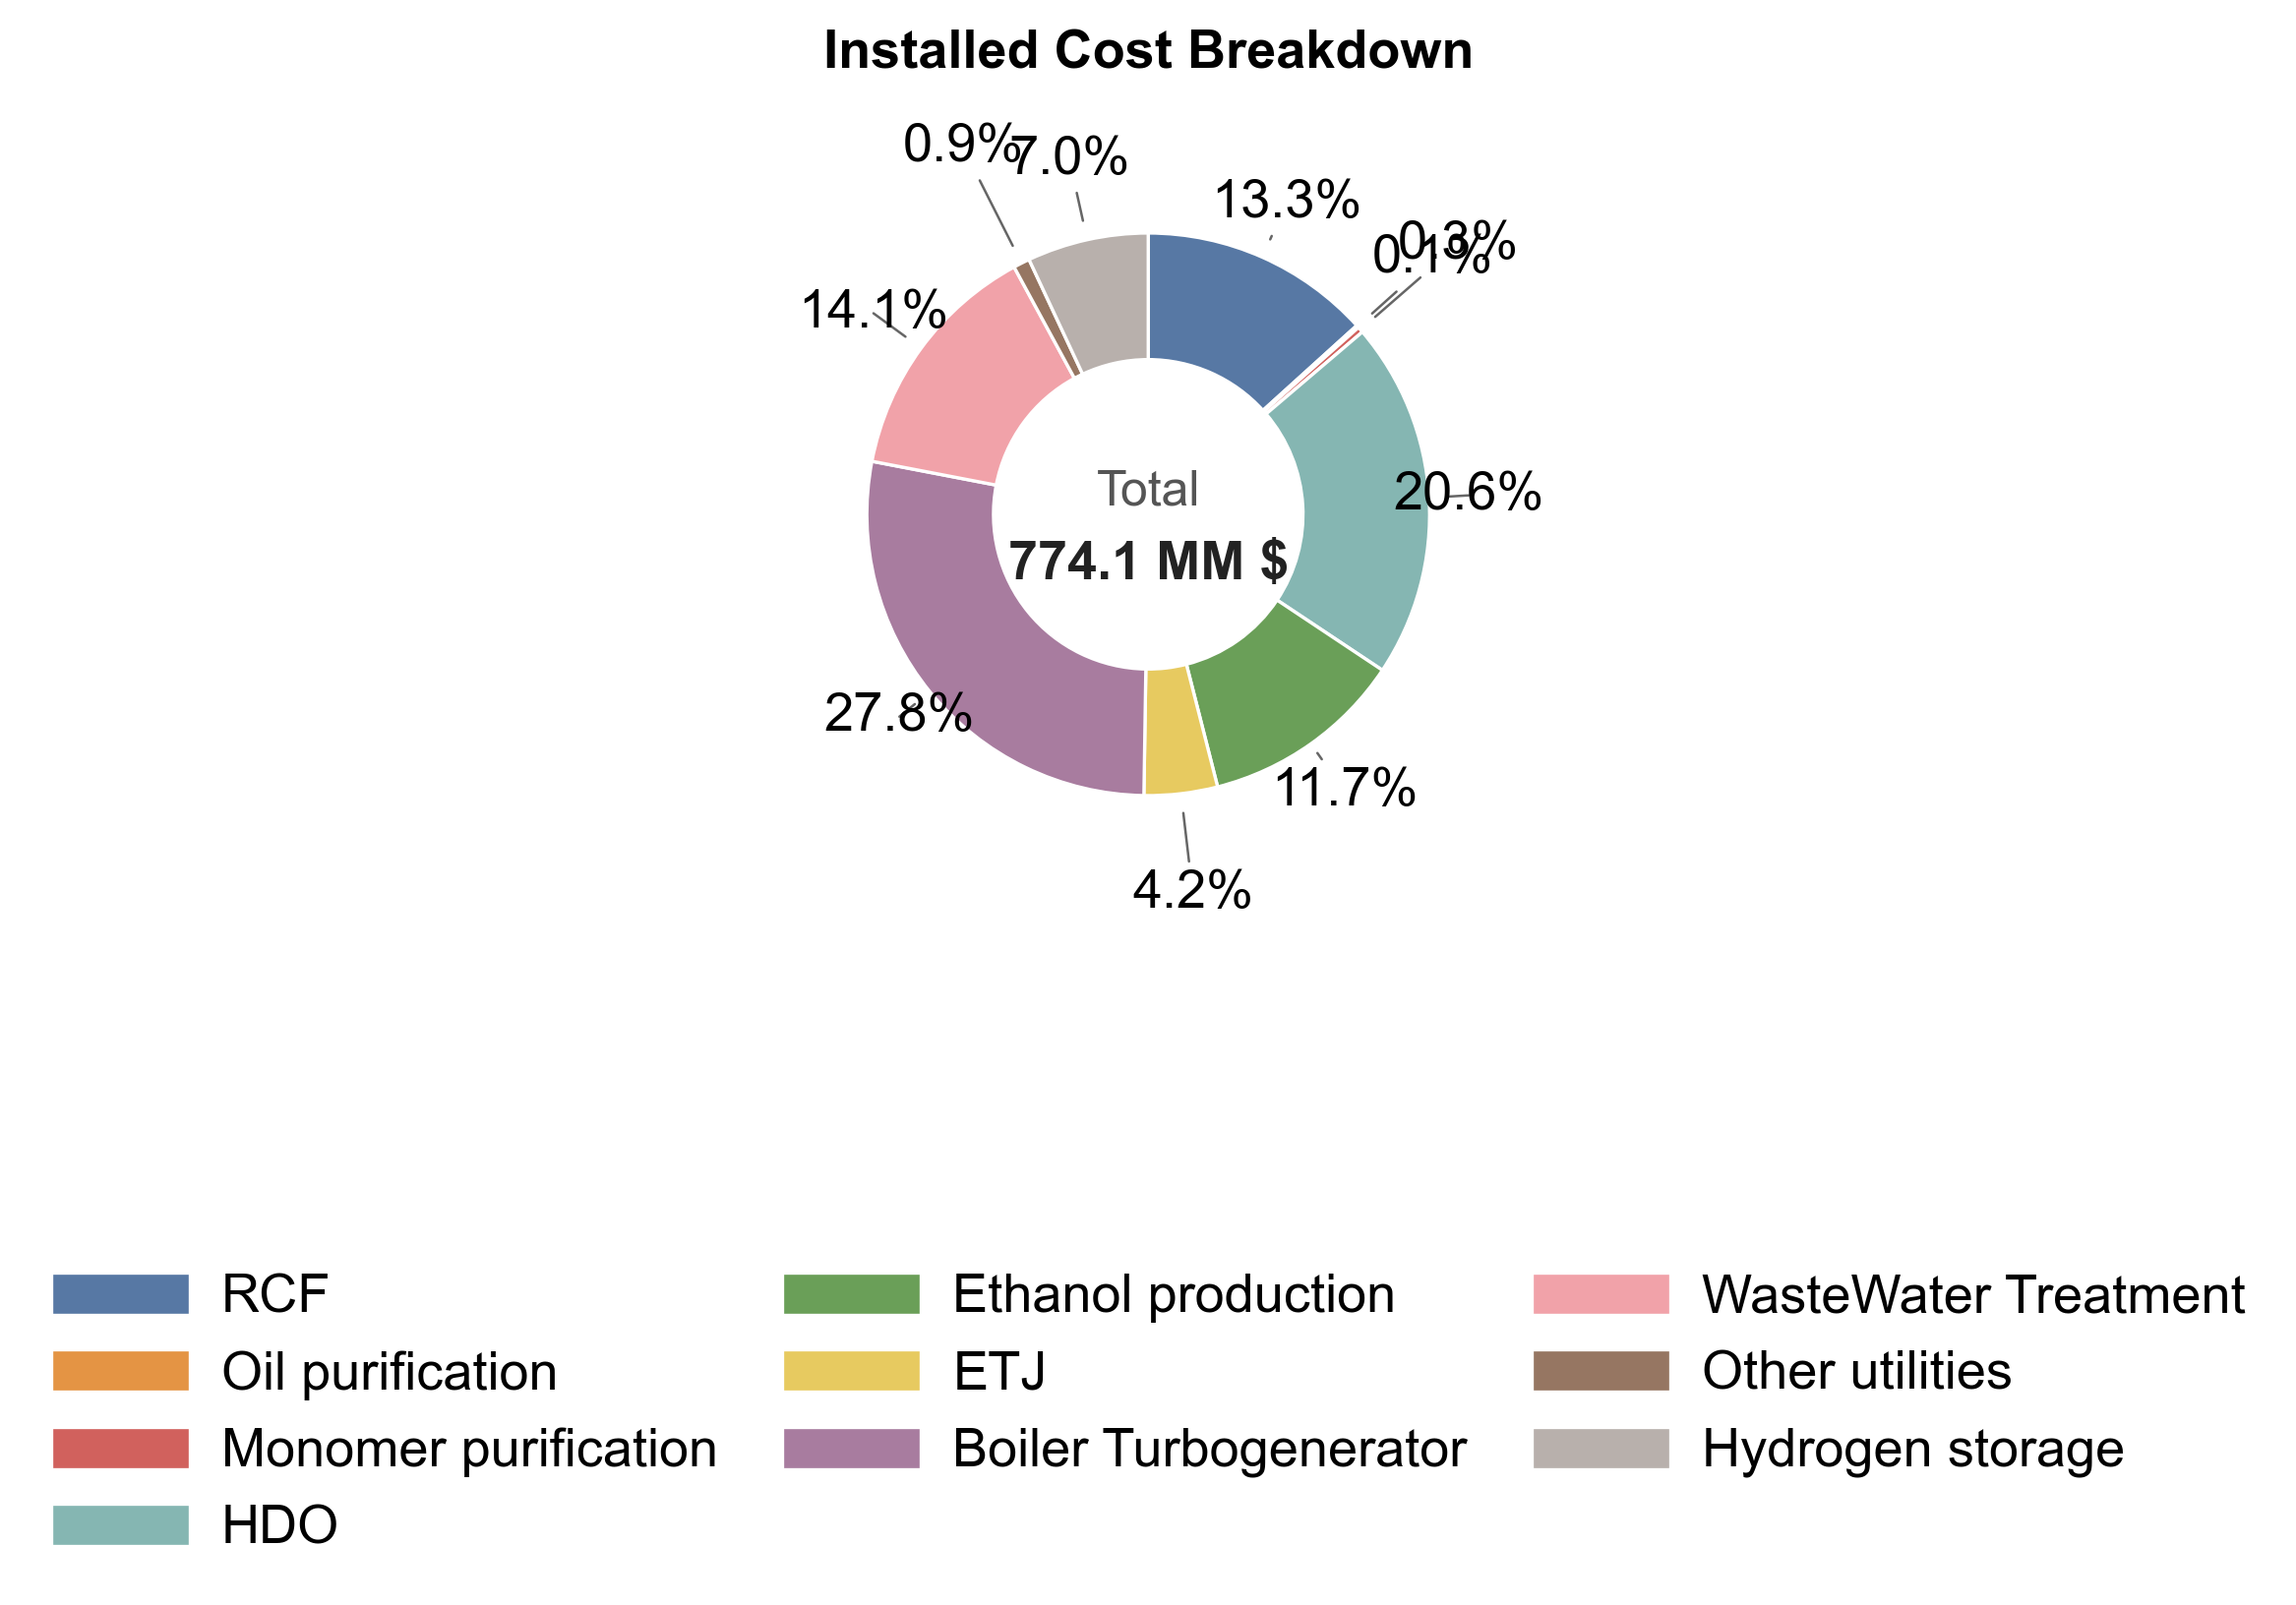

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})
plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    '#5778a4', '#e49444', '#d1615d', '#85b6b2', '#6a9f58',
    '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac', "#8D86C9"
]

categories = [
    "RCF", "Oil purification", "Monomer purification", "HDO",
    "Ethanol production", "ETJ", "Boiler Turbogenerator",
    "WasteWater Treatment", "Other utilities", "Hydrogen storage"
]

values = [
    rcf_area_ic, rcf_oil_purification_ic, rcf_monomer_purification_ic,
    hdo_ic, etoh_ic, etj_ic, BT_installed_cost, WWT_installed_cost,
    other_utilities_ic, h2_storage_ic
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_in = 1500 / DPI
fig_h_in = 1260 / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13
FS_LEGEND = 13

DONUT_WIDTH = 0.45   # ← controls ring thickness (0–1); increase to thicken

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

def draw_donut(ax, vals, title):
    total = sum(vals)
    fracs = [v / total for v in vals]

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors[:len(vals)],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(
            width=DONUT_WIDTH,          # ← this creates the donut hole
            linewidth=0.8,
            edgecolor="white"
        ),
    )

    # ── Center label (replaces the below-chart total) ─────────────────────
    total_mm = total / 1e6
    ax.text(0, 0.08, "Total", ha="center", va="center",
            fontsize=FS_TOTAL - 1, color="#555555")
    ax.text(0, -0.18,
            f"{rcf_pure_mon_hdo_etoh_etj_system.installed_cost/1e6:.1f} MM $",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#222222")

    # ── Percentage labels with leader lines ───────────────────────────────
    # r_in points to the outer edge of the ring; r_out to the label
    r_ring_outer = 1.0
    r_ring_inner = r_ring_outer - DONUT_WIDTH

    label_data = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        if pct >= 20:   r_out = 1.14
        elif pct >= 10: r_out = 1.21
        elif pct >= 5:  r_out = 1.29
        else:           r_out = 1.38
        label_data.append(dict(theta=theta, pct=pct, r_out=r_out, idx=i))

    small_indices = [d["idx"] for d in label_data if d["pct"] < 5]
    for j, idx in enumerate(small_indices):
        label_data[idx]["r_out"] = 1.36 if j % 2 == 0 else 1.46

    for d in label_data:
        theta, r_out, pct = d["theta"], d["r_out"], d["pct"]
        # Arrow starts just outside the ring
        r_arrow_start = r_ring_outer + 0.04
        ax.annotate(
            f"{pct:.1f}%",
            xy=(r_arrow_start * np.cos(theta), r_arrow_start * np.sin(theta)),
            xytext=(r_out * np.cos(theta), r_out * np.sin(theta)),
            fontsize=FS_PCT,
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-", color="#666666", lw=0.6,
                shrinkA=0, shrinkB=2,
            ),
        )

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=6)
    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.75, 1.50)

draw_donut(ax, values, "Installed Cost Breakdown")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.8, label=lbl)
    for c, lbl in zip(oi_colors, categories)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.6,
    handleheight=0.85,
    handletextpad=0.6,
    bbox_to_anchor=(0.5, 0.0),
)

plt.rcParams['svg.fonttype'] = 'none'
fig.tight_layout(rect=[0, 0.14, 1, 1])

# fig.savefig("installed_cost_breakdown_2.svg", format="svg", bbox_inches="tight")

In [ ]:
F.ETJ_RXR1.results()

Adiabatic reactor                              Units  ETJ_RXR1
Design              Vessel type                       Vertical
                    Length                        ft      53.3
                    Diameter                      ft      17.8
                    Weight                            2.57e+05
                    Wall thickness                in      1.55
                    Catalyst Weight               kg  2.35e+05
                    Volume                         L  3.75e+05
                    Duty                       kJ/hr         0
Purchase cost       Vertical pressure vessel     USD  1.35e+06
                    Platform and ladders         USD  8.49e+04
                    Catalyst loading cost        USD  8.64e+06
Total purchase cost                              USD  1.01e+07
Utility cost                                  USD/hr         0

In [ ]:
F.ETJ_H2TK

AttributeError: no registered item 'ETJ_H2TK'

In [ ]:
(F.ethanol.F_mass*24*330)/1e7

16.73039334711034

In [ ]:
(4.8 * 773.94) /264.172       # [USD/kg]


14.062474448465393

In [ ]:
(3.74 * 264.172) / 773.94

1.2765889862263224